#### 머신러닝 프레임워크 : scikit-learn (sk-learn)
: 다양한 분류(Classification : 객관식) 및 회귀(Regression : 주관식)를 지원하며 검증하는 기능    
분류, 회귀, 클러스터링, 차원축소가 가능하며 샘플 데이터도 제공한다.

#### XOR(Exclusive OR)연산 학습해보기

In [1]:
xor_input = [
    [0, 0, 0],
    [0, 1, 1],
    [1, 0, 1],
    [1, 1, 0]
]
xor_input

[[0, 0, 0], [0, 1, 1], [1, 0, 1], [1, 1, 0]]

In [2]:
import pandas as pd

In [4]:
# .을 사용하는 방식은 메서드 / () 안에 넣는 방식은 function
xor_df = pd.DataFrame(xor_input)
xor_df

,0,1,2
0,0,0,0
1,0,1,1
2,1,0,1
3,1,1,0


In [6]:
# 데이터 구성 (문제)
xor_data = xor_df.loc[:, [0, 1]]
xor_data

,0,1
0,0,0
1,0,1
2,1,0
3,1,1


In [8]:
# 정답
xor_target = xor_df.loc[:,2]
xor_target
# Series 타입

0    0
1    1
2    1
3    0
Name: 2, dtype: int64

In [9]:
# 데이터 학습과 예측하기
from sklearn import svm, metrics

In [10]:
# 모델 만들기
clf = svm.SVC()

In [12]:
# 학습 시키기 (지도학습)
clf.fit(xor_data, xor_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [13]:
# 평가
pred = clf.predict(xor_data)
pred

array([0, 1, 1, 0])

In [14]:
# 정답률 구하기
metrics.accuracy_score(xor_target, pred) # xor_target = y, pred = y hat

1.0

In [15]:
# predict를 구하지 않고 정답률 구하기
clf.score(xor_data, xor_target)

1.0

----
### 붓꽃의 품종 분류하기

In [16]:
iris = pd.read_csv('../Data/iris.csv')
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [17]:
iris.tail()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [19]:
# 품종의 종류?
iris['Name'].unique()

array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [24]:
# Data Type
iris.info()
iris.dtypes

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  150 non-null    float64
 1   SepalWidth   150 non-null    float64
 2   PetalLength  150 non-null    float64
 3   PetalWidth   150 non-null    float64
 4   Name         150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


SepalLength    float64
SepalWidth     float64
PetalLength    float64
PetalWidth     float64
Name            object
dtype: object

In [25]:
# 기본 통계량
iris.describe()

,SepalLength,SepalWidth,PetalLength,PetalWidth
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


- 중앙값과 평균값이 비슷할 경우 - 데이터가 정규분포 라는 것을 알 수 있다
- 비정규분포는 분석해도 엉터리

In [27]:
# NaN(Not a Number) 값 확인
iris.isna().sum()

SepalLength    0
SepalWidth     0
PetalLength    0
PetalWidth     0
Name           0
dtype: int64

#### Color Feature 추가

In [37]:
# Iris-setosa: red, Iris-versicolor: green, Iris-virginica: blue
color_tmp = []

for name in iris['Name']:
    if name == 'Iris-setosa':
        color_tmp.append('red')
    elif name == 'Iris-versicolor':
        color_tmp.append('green')
    else:
        color_tmp.append('blue')

iris['Color'] = color_tmp
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,Color
0,5.1,3.5,1.4,0.2,Iris-setosa,red
1,4.9,3.0,1.4,0.2,Iris-setosa,red
2,4.7,3.2,1.3,0.2,Iris-setosa,red
3,4.6,3.1,1.5,0.2,Iris-setosa,red
4,5.0,3.6,1.4,0.2,Iris-setosa,red


### 산포도(산점도, Scatter)

In [30]:
import matplotlib.pyplot as plt

In [ ]:
#!pip install koreanize-matplotlib

   ---------------------------------------- 0.0/7.9 MB ? eta -:--:--
   ----- ---------------------------------- 1.0/7.9 MB 13.4 MB/s eta 0:00:01
   ----------- ---------------------------- 2.4/7.9 MB 7.0 MB/s eta 0:00:01
   --------------------------- ------------ 5.5/7.9 MB 10.2 MB/s eta 0:00:01
   ---------------------------------------  7.9/7.9 MB 10.6 MB/s eta 0:00:01
   ---------------------------------------- 7.9/7.9 MB 10.2 MB/s  0:00:00


In [43]:
import koreanize_matplotlib

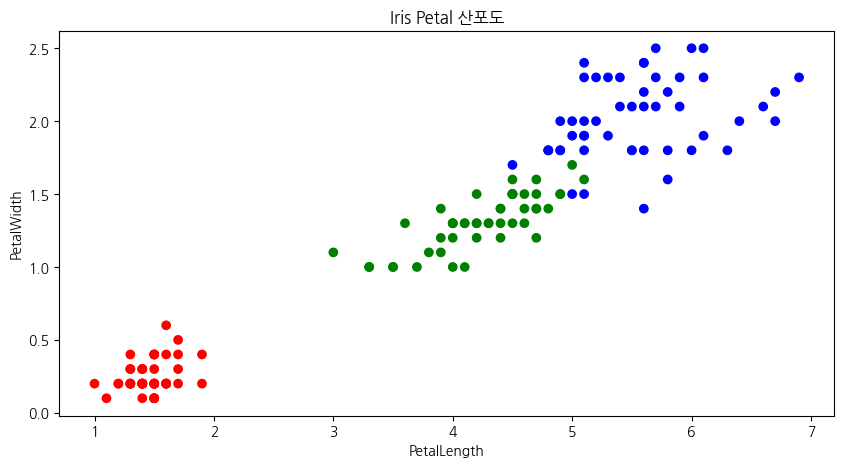

In [44]:
plt.figure(figsize=(10, 5))

plt.scatter(
    iris['PetalLength'],
    iris['PetalWidth'],
    c=iris['Color']
)

plt.xlabel('PetalLength')
plt.ylabel('PetalWidth')
plt.title('Iris Petal 산포도')

plt.show()

### Machine Learning 을 위한 작업

In [53]:
iris.head()

,SepalLength,SepalWidth,PetalLength,PetalWidth,Name,Color
0,5.1,3.5,1.4,0.2,Iris-setosa,red
1,4.9,3.0,1.4,0.2,Iris-setosa,red
2,4.7,3.2,1.3,0.2,Iris-setosa,red
3,4.6,3.1,1.5,0.2,Iris-setosa,red
4,5.0,3.6,1.4,0.2,Iris-setosa,red


In [63]:
    # 지도 학습의 Feature 만들기
    iris_data = iris[
        ['SepalLength',
        'SepalWidth',
        'PetalLength',
        'PetalWidth']
    ]
    iris_data

,SepalLength,SepalWidth,PetalLength,PetalWidth
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [64]:
# Target
iris_target = iris['Name']
iris_target.head()

0    Iris-setosa
1    Iris-setosa
2    Iris-setosa
3    Iris-setosa
4    Iris-setosa
Name: Name, dtype: object

### 학습용 데이터와 테스트용 데이터로 나누기

In [56]:
from sklearn.model_selection import train_test_split

In [65]:
train_test_split(iris_data, iris_target)
train_data, test_data, train_target, test_target = \
    train_test_split(iris_data, iris_target)

In [66]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 38 entries, 93 to 127
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   SepalLength  38 non-null     float64
 1   SepalWidth   38 non-null     float64
 2   PetalLength  38 non-null     float64
 3   PetalWidth   38 non-null     float64
dtypes: float64(4)
memory usage: 1.5 KB


### 학습시키기

In [67]:
clf = svm.SVC()

In [68]:
clf.fit(train_data, train_target)

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [69]:
pred = clf.predict(test_data)
pred[:5]

array(['Iris-versicolor', 'Iris-virginica', 'Iris-versicolor',
       'Iris-setosa', 'Iris-versicolor'], dtype=object)

In [70]:
metrics.accuracy_score(test_target, pred)

0.8947368421052632

In [71]:
# SepalLength  4.1, SepalWidth : 3.5, PetalLength : 1.4, PetalWidth : 0.2
clf.predict([
    [4.1, 3.5, 1.4, 0.2]
])

c:\Users\tuxca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-setosa'], dtype=object)

In [73]:
# SepalLength  8.1, SepalWidth : 9.5, PetalLength : 11.4, PetalWidth : 1.2
clf.predict([
    [8.1, 9.5, 11.4, 1.2]
])
# 데이터 값과 일치하지 않는 데이터 값을 제공해도 추론값을 출력함. 때문에 AI에게 정확한 데이터를 넘겨줄 필요가 있다.

c:\Users\tuxca\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but SVC was fitted with feature names
  warnings.warn(


array(['Iris-virginica'], dtype=object)